# Import Library

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import l2

VersionError: Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow/core/framework/attr_value.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.

In [ ]:
X_train = pd.read_csv('X_train final.csv').values
y_train = pd.read_csv('y_train final.csv').values
X_test = pd.read_csv('X_test final.csv').values
y_test = pd.read_csv('y_test final.csv').values

input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

# Proses Modelling

In [ ]:
def build_fintrack_model():
    inputs = tf.keras.Input(shape=(input_dim,))

    x = layers.Dense(64, activation='relu', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(16, activation='relu')(x)


    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs, name="FinTrack_Classifier")
    return model

model = build_fintrack_model()

In [ ]:
class finTracktargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        mae = logs.get('mae')

        if acc is not None and mae is not None:
            if acc >= 0.85 and mae <= 0.02:
                print(f"\n[info] target tercapai di epoch {epoch+1}!")
                print(f"Akurasi: {acc:.4f}, MAE: {mae:.4f}. menghentikan training...")
                self.model.stop_training = True

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'mae']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[finTracktargetCallback()],
    verbose=1
)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6970 - loss: 1.2674 - mae: 0.3844 - val_accuracy: 0.9215 - val_loss: 1.1147 - val_mae: 0.3470
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8729 - loss: 0.9883 - mae: 0.2489 - val_accuracy: 0.9895 - val_loss: 0.8688 - val_mae: 0.2070
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9564 - loss: 0.7651 - mae: 0.1252 - val_accuracy: 1.0000 - val_loss: 0.6821 - val_mae: 0.0945
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9756 - loss: 0.6510 - mae: 0.0761 - val_accuracy: 1.0000 - val_loss: 0.5731 - val_mae: 0.0419
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9884 - loss: 0.5664 - mae: 0.0478 - val_accuracy: 1.0000 - val_loss: 0.5008 - val_mae: 0.0211
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9897 - loss: 0.5037 - mae: 0.0374 - val_accuracy: 1.0000 - val_loss: 0.4419 - val_mae: 0.0108
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

# Visualisasi

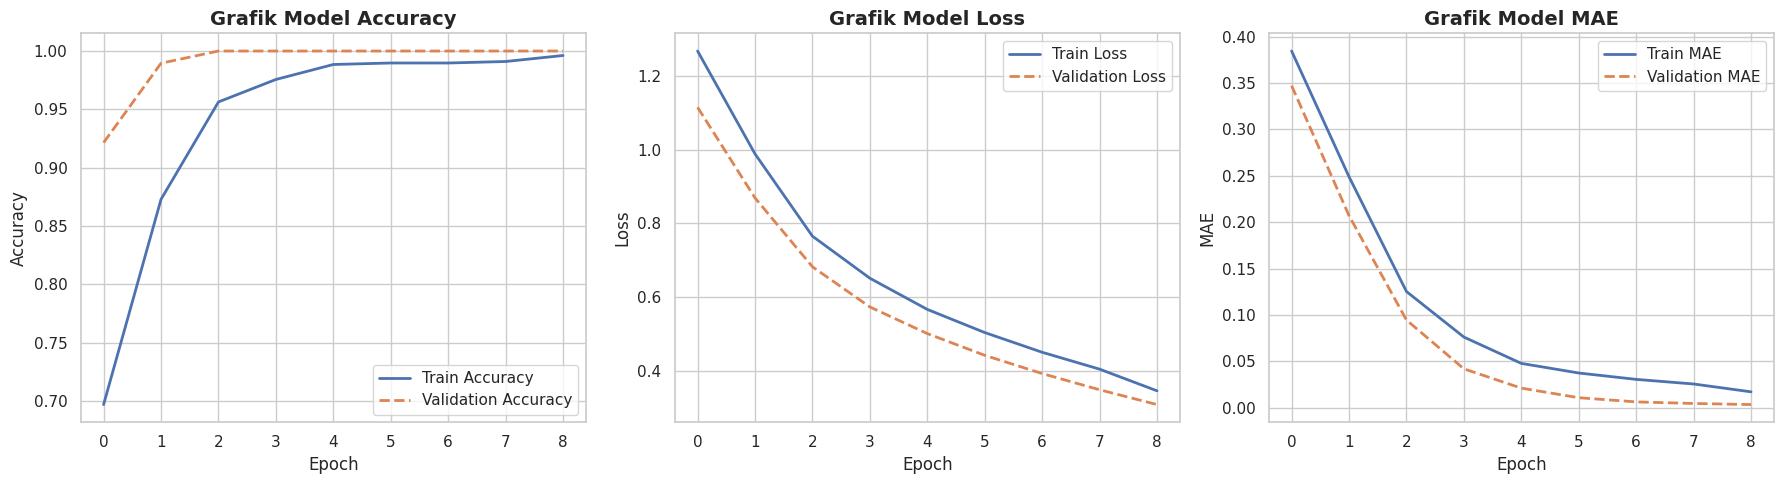

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------
# Grafik akurasi (Accuracy)
# ---------------------------------------------------
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='#4C72B0', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#DD8452', linewidth=2, linestyle='--')
axes[0].set_title('Grafik Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')

# ---------------------------------------------------
# Grafik loss (Binary Crossentropy)
# ---------------------------------------------------
axes[1].plot(history.history['loss'], label='Train Loss', color='#4C72B0', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#DD8452', linewidth=2, linestyle='--')
axes[1].set_title('Grafik Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

# ---------------------------------------------------
# Grafik MAE (Mean Absolute Error)
# ---------------------------------------------------
axes[2].plot(history.history['mae'], label='Train MAE', color='#4C72B0', linewidth=2)
axes[2].plot(history.history['val_mae'], label='Validation MAE', color='#DD8452', linewidth=2, linestyle='--')
axes[2].set_title('Grafik Model MAE', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MAE')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Simpan model

In [ ]:
model.save("fintrack_model.keras")
print("Model berhasil disimpan dalam format fintrack_model.keras")

Model berhasil disimpan dalam format fintrack_model.keras


# Proses Inference Sederhana

In [ ]:
model_fintrack = tf.keras.models.load_model("fintrack_model.keras")

profil_keuangan = {
    0: "Mahasiswa terencana (Prioritas kebutuhan pokok & kos)",
    1: "Mahasiswa konsumtif (Tinggi di hiburan & sosial)"
}

def predict_user_profile(data_input_user):
    prediksi_probabilitas = model_fintrack.predict(data_input_user)

    nilai_prob = float(prediksi_probabilitas[0][0])

    if nilai_prob >= 0.5:
        cluster_id = 1
    else:
        cluster_id = 0

    hasil_prediksi = {
        "status": "success",
        "cluster_id": cluster_id,
        "kesimpulan": profil_keuangan[cluster_id],
        "confidence_score": round(nilai_prob, 4)
    }

    return hasil_prediksi

data_dummy_dari_web = pd.read_csv('X_test final.csv').values[:1]

hasil = predict_user_profile(data_dummy_dari_web)
print("Data:", hasil)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
Data: {'status': 'success', 'cluster_id': 0, 'kesimpulan': 'Mahasiswa terencana (Prioritas kebutuhan pokok & kos)', 'confidence_score': 0.0098}


# Fitur Finbot (Tambahan)

In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.6 MB/s eta 0:00:00


In [ ]:
# import os
# from groq import Groq

# # API Key
# DAFTAR_API= [
# ]

# # variabel untuk melacak urutan kunci mana yang sedang dipakai
# index_key_groq = 0

# def chatbot_finbot(pertanyaan_user, profil_cluster_ds, saldo_saat_ini):
#     global index_key_groq
#     jumlah_kunci = len(DAFTAR_API)
#     percobaan = 0

#     system_prompt = f"""
#     Kamu adalah 'FinBot', asisten penasihat keuangan pintar dan empatik di aplikasi FinTrack.
#     Gaya bahasamu asyik, suportif, dan kekinian (cocok untuk Gen Z / Mahasiswa).

#     Konteks profil pengguna saat ini:
#     - Kategori pengguna: {profil_cluster_ds}
#     - Sisa saldo saat ini: Rp {saldo_saat_ini:,}

#     Aturan menjawab:
#     1. Jawab pertanyaan pengguna berdasarkan profil dan sisa saldo mereka.
#     2. Jawab dengan singkat, padat, dan solutif (maksimal 3 paragraf).
#     """

#     # menggunakan rotation jika salah satu api terkena batas limit
#     while percobaan < jumlah_kunci:
#         kunci_saat_ini = DAFTAR_API[index_key_groq]

#         try:
#             # Inisialisasi client dengan kunci yang sedang aktif
#             client = Groq(api_key=kunci_saat_ini)

#             chat_completion = client.chat.completions.create(
#                 messages=[
#                     {"role": "system", "content": system_prompt},
#                     {"role": "user", "content": pertanyaan_user}
#                 ],
#                 model="llama-3.3-70b-versatile", # model yang digunakan
#                 temperature=0.7,
#                 max_tokens=500
#             )

#             return chat_completion.choices[0].message.content

#         except Exception as e:
#             # pindah ke kunci kedua (atau kembali ke kunci pertama jika sudah di ujung)
#             index_key_groq = (index_key_groq + 1) % jumlah_kunci
#             percobaan += 1


#     # pesan error final (Jika ketiga kunci mati/limit)
#     pesan_error_final = (
#         "Waduh, server FinBot lagi kepenuhan nih! "
#     )
#     return pesan_error_final


# # Uji Coba
# data_cluster_user = "Mahasiswa boros (sering habis uang di hiburan & makanan)"
# data_saldo_user = 150000
# pertanyaan = "eh FinBot, temen-temen kelasan ngajak nongkrong ke kafe mahal nih nanti malam. gimana ya?"

# print("Mengirim data ke FinBot...")
# jawaban_ai = chatbot_finbot(pertanyaan, data_cluster_user, data_saldo_user)

# print("\n🧑‍💻 User   :", pertanyaan)
# print("-" * 50)
# print("🤖 FinBot :", jawaban_ai)

Mengirim data ke FinBot...

🧑‍💻 User   : eh FinBot, temen-temen kelasan ngajak nongkrong ke kafe mahal nih nanti malam. gimana ya?
--------------------------------------------------
🤖 FinBot : Kamu lagi dihadapkan pada pilihan yang sulit nih. Temen-temen ngajak nongkrong, tapi uangmu tidak banyak. Sisa saldo kamu saat ini hanya Rp 150,000, dan kafe mahal biasanya bisa menghabiskan uang lebih dari Rp 50,000 per orang. 

Coba kamu pertimbangkan dulu, apakah nongkrong di kafe mahal itu benar-benar penting untuk kamu? Atau kamu bisa mencari alternatif lain yang lebih murah, seperti nongkrong di kantin kampus atau di rumah salah satu temenmu? Dengan begitu, kamu bisa tetap bersosialisasi tanpa menghabiskan uang terlalu banyak. 

Jika kamu tetap ingin nongkrong di kafe mahal, pastikan kamu untuk membuat anggaran yang jelas dan tidak menghabiskan uang lebih dari yang kamu miliki. Mungkin kamu bisa memilih menu yang lebih murah atau berbagi makanan dengan temen-temenmu. Ingat, uangmu harus cuk

In [ ]:
import os
import joblib
import pandas as pd
from groq import Groq

# =====================================================================
# 1. KONFIGURASI API KEY (SISTEM ROTASI GROQ)
# =====================================================================
DAFTAR_API = [
]
index_key_groq = 0

# Load hasil clustreing & scaler
scaler = joblib.load("scaler final (1).pkl")
model_kmeans = joblib.load("model_clustering final.pkl")

PROFIL_CLUSTER = {
    0: "Mahasiswa hemat (Disiplin, pengeluaran pokok saja)",
    1: "Mahasiswa boros (Sering habis uang di hiburan & makanan)",
    2: "Mahasiswa strategis (Uang pas-pasan tapi pintar atur porsi)"
}

NAMA_KOLOM = [
    'age', 'gender', 'year_in_school', 'major', 'monthly_income',
    'financial_aid', 'tuition', 'housing', 'food', 'transportation',
    'books_supplies', 'entertainment', 'personal_care', 'technology',
    'health_wellness', 'miscellaneous', 'preferred_payment_method',
    'total_spending', 'saving_ratio', 'spending_level'
]

# =====================================================================
# 3. FUNGSI UTAMA 1: PREDIKSI CLUSTER OTOMATIS (BEBAS WARNING)
# =====================================================================
def dapatkan_profil_otomatis(data_transaksi_user):
    # Mengubah list menjadi DataFrame agar scikit-learn tidak memunculkan UserWarning
    df_input = pd.DataFrame([data_transaksi_user], columns=NAMA_KOLOM)

    # Standarisasi data & prediksi cluster
    data_scaled = scaler.transform(df_input)
    cluster_id = model_kmeans.predict(data_scaled)[0]

    return PROFIL_CLUSTER[cluster_id]

# =====================================================================
# 4. FUNGSI UTAMA 2: CHATBOT FINBOT WITH SYSTEM PROMPT
# =====================================================================
def chatbot_finbot(pertanyaan_user, profil_cluster_ds, saldo_saat_ini):
    global index_key_groq
    jumlah_kunci = len(DAFTAR_API)
    percobaan = 0

    system_prompt = f"""
    Kamu adalah 'FinBot', asisten penasihat keuangan pintar dan empatik di aplikasi FinTrack.
    Gaya bahasamu asyik, suportif, dan kekinian (cocok untuk Gen Z / Mahasiswa).

    Konteks profil pengguna saat ini:
    - Kategori pengguna: {profil_cluster_ds}
    - Sisa saldo saat ini: Rp {saldo_saat_ini:,}

    Aturan menjawab:
    1. Jawab pertanyaan pengguna berdasarkan profil dan sisa saldo mereka.
    2. Jawab dengan singkat, padat, dan solutif (maksimal 3 paragraf).
    """

    while percobaan < jumlah_kunci:
        kunci_saat_ini = DAFTAR_API[index_key_groq]
        try:
            client = Groq(api_key=kunci_saat_ini)
            chat_completion = client.chat.completions.create(
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": pertanyaan_user}
                ],
                model="llama-3.3-70b-versatile",
                temperature=0.7,
                max_tokens=500
            )
            return chat_completion.choices[0].message.content
        except Exception as e:
            # Jika limit, geser ke API Key berikutnya otomatis
            index_key_groq = (index_key_groq + 1) % jumlah_kunci
            percobaan += 1

    return "Waduh, server FinBot lagi kepenuhan nih! Coba beberapa saat lagi ya."


# JALANKAN SKENARIO UJI COBA

# Simulasi data transaksi riil (Harus 20 angka sesuai urutan NAMA_KOLOM)
data_transaksi_budi = [
    20, 1, 0, 2,        # age, gender, year_in_school, major
    2000000, 500000,    # monthly_income, financial_aid
    1500000, 800000,    # tuition, housing
    400000, 150000,     # food, transportation
    100000, 200000,     # books_supplies, entertainment
    50000, 120000,      # personal_care, technology
    80000, 30000,       # health_wellness, miscellaneous
    1,                  # preferred_payment_method
    3430000, 0.15, 2    # total_spending, saving_ratio, spending_level
]
saldo_sekarang = 150000
pertanyaan = "eh FinBot, temen-temen kelasan ngajak nongkrong ke kafe mahal nih nanti malam. gimana ya?"

# Eksekusi Pipeline AI
cluster_otomatis = dapatkan_profil_otomatis(data_transaksi)
jawaban_ai = chatbot_finbot(pertanyaan, cluster_otomatis, saldo_sekarang)

# Tampilkan hasil akhir
print("\n" + "="*60)
print("")
print("="*60)
print(f"Hasil deteksi cluster   : {cluster_otomatis}")
print(f"Sisa saldo user         : Rp {saldo_sekarang:,}")
print(f"Pertanyaan user         : '{pertanyaan}'")
print("-"*60)
print("Respon Finbot :")
print(jawaban_ai)
print("="*60)

⏳ Sedang memproses data Budi ke Model Machine Learning...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(




Hasil deteksi cluster  : Mahasiswa Hemat (Disiplin, pengeluaran pokok saja)
Sisa saldo user         : Rp 150,000
Pertanyaan user         : 'eh FinBot, temen-temen kelasan ngajak nongkrong ke kafe mahal nih nanti malam. gimana ya?'
------------------------------------------------------------
Respon Finbot :
Bruh, aku paham kamu pengen bergaul sama temen-temen, tapi kamu juga harus ingat bahwa kamu punya target hemat, kan? Sisa saldo kamu saat ini Rp 150,000, dan nongkrong di kafe mahal bisa bikin kamu jebol dompet.

Mungkin kamu bisa ajak temen-temen untuk cari alternatif yang lebih murah, seperti nongkrong di kantin kampus atau cari tempat makan yang lebih terjangkau. Atau, jika kamu masih ingin bergabung, kamu bisa siapin budget yang pas dan tidak berlebihan, sehingga kamu tidak kehabisan dana.

Aku sarankan kamu untuk membuat prioritas, bro. Apakah nongkrong di kafe mahal itu benar-benar penting untuk kamu, atau kamu bisa mencari kegiatan lain yang lebih sesuai dengan budget kamu? 